# DSA 210 Term Project: Machine Learning Analysis of UEFA Champions League Away Performances

**Student:** Murat Kabaağaç - [00033797]

## Part 1: Importing Libraries and Loading the ML Dataset

In this notebook, I focus on the machine learning stage of the project. Using the enriched UEFA Champions League dataset prepared in the previous notebook, I will train and evaluate baseline classification models to investigate whether away-team wins can be predicted from travel-distance and weather-related variables.

In this first step, I import the required Python libraries and load the final machine-learning dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving ml_enriched_dataset.csv to ml_enriched_dataset.csv


In [14]:
ml_df = pd.read_csv("ml_enriched_dataset.csv")

print("Part 1: ML dataset loaded successfully!")
ml_df.head()

Part 1: ML dataset loaded successfully!


,date,home_club_name,away_club_name,home_club_goals,away_club_goals,stadium,attendance,away_win,away_not_lose,away_goal_difference,...,temperature_2m_mean,precipitation_sum,windspeed_10m_max,club_name,home_stadium,home_city,home_country,home_latitude,home_longitude,travel_distance_km
0,2012-09-18,GNK Dinamo Zagreb,Futebol Clube do Porto,0,2,Maksimir,4683.0,1,1,2,...,19.3,0.1,6.8,Futebol Clube do Porto,Estádio do Dragão,Porto,Portugal,41.1614,-8.5835,2046.686308
1,2012-09-18,Paris Saint-Germain Football Club,Futbolniy Klub Dynamo Kyiv,4,1,Parc des Princes,42536.0,0,0,-3,...,15.8,0.0,16.2,Futbolniy Klub Dynamo Kyiv,NSK Olimpisky,Kyiv,Ukraine,50.4338,30.5218,2037.194130
2,2012-09-18,Montpellier HSC,Arsenal Football Club,1,2,Stade de la Mosson,27522.0,1,1,1,...,19.7,0.3,15.9,Arsenal Football Club,Emirates Stadium,London,England,51.5549,-0.1084,929.843828
3,2012-09-18,Olympiakos Syndesmos Filathlon Peiraios,FC Schalke 04,1,2,Stadio Georgios Karaiskakis,30922.0,1,1,1,...,22.8,0.0,9.7,FC Schalke 04,Veltins-Arena,Gelsenkirchen,Germany,51.5542,7.0678,1995.039270
4,2012-09-18,Málaga CF,AO FK Zenit Sankt-Peterburg,3,0,La Rosaleda,23670.0,0,0,-3,...,25.9,0.0,6.5,AO FK Zenit Sankt-Peterburg,Gazprom Arena,Saint Petersburg,Russia,59.9727,30.2211,3568.832469


In [4]:
print("Shape of the ML dataset:", ml_df.shape)

print("\nColumn names:")
for col in ml_df.columns:
    print(col)

Shape of the ML dataset: (1856, 25)

Column names:
date
home_club_name
away_club_name
home_club_goals
away_club_goals
stadium
attendance
away_win
away_not_lose
away_goal_difference
stadium_name
city
country
latitude
longitude
temperature_2m_mean
precipitation_sum
windspeed_10m_max
club_name
home_stadium
home_city
home_country
home_latitude
home_longitude
travel_distance_km


In [5]:
print("Missing values in each column:")
print(ml_df.isnull().sum())

Missing values in each column:
date                      0
home_club_name            0
away_club_name            0
home_club_goals           0
away_club_goals           0
stadium                   0
attendance              126
away_win                  0
away_not_lose             0
away_goal_difference      0
stadium_name              0
city                      0
country                   0
latitude                  0
longitude                 0
temperature_2m_mean       6
precipitation_sum         6
windspeed_10m_max         6
club_name                 0
home_stadium              0
home_city                31
home_country             31
home_latitude            31
home_longitude           31
travel_distance_km       31
dtype: int64


At this stage, the machine-learning dataset has been successfully loaded into the notebook. In the next step, I will inspect the target variable and select the most relevant features for the first baseline classification models.

## Part 2: Inspecting the Target Variable and Selecting Features

In this step, I define the target variable for the first machine learning task and select the most relevant input features. I use away-team win as the target variable and focus on travel distance and weather-related numerical variables as predictors. I also remove rows with missing values in the selected columns to prepare a clean dataset for model training.

In [6]:
print("Target variable distribution (away_win):")
print(ml_df["away_win"].value_counts())

Target variable distribution (away_win):
away_win
0    1255
1     601
Name: count, dtype: int64


In [7]:
print("Target variable proportions (away_win):")
print(ml_df["away_win"].value_counts(normalize=True))

Target variable proportions (away_win):
away_win
0    0.676185
1    0.323815
Name: proportion, dtype: float64


As the target variable, I use `away_win`, which indicates whether the away team won the match. Before training the models, I inspect the class balance to understand whether the dataset is highly imbalanced.

In [8]:
selected_features = [
    "temperature_2m_mean",
    "precipitation_sum",
    "windspeed_10m_max",
    "travel_distance_km"
]

target_variable = "away_win"

print("Selected features:", selected_features)
print("Target variable:", target_variable)

Selected features: ['temperature_2m_mean', 'precipitation_sum', 'windspeed_10m_max', 'travel_distance_km']
Target variable: away_win


In [9]:
ml_clean_df = ml_df[selected_features + [target_variable]].dropna().copy()

print("Shape before ML cleaning:", ml_df.shape)
print("Shape after ML cleaning:", ml_clean_df.shape)
ml_clean_df.head()

Shape before ML cleaning: (1856, 25)
Shape after ML cleaning: (1819, 5)


,temperature_2m_mean,precipitation_sum,windspeed_10m_max,travel_distance_km,away_win
0,19.3,0.1,6.8,2046.686308,1
1,15.8,0.0,16.2,2037.194130,0
2,19.7,0.3,15.9,929.843828,1
3,22.8,0.0,9.7,1995.039270,1
4,25.9,0.0,6.5,3568.832469,0


In [10]:
print("Missing values after ML cleaning:")
print(ml_clean_df.isnull().sum())

Missing values after ML cleaning:
temperature_2m_mean    0
precipitation_sum      0
windspeed_10m_max      0
travel_distance_km     0
away_win               0
dtype: int64


In [11]:
X = ml_clean_df[selected_features]
y = ml_clean_df[target_variable]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (1819, 4)
Target vector shape: (1819,)


In [12]:
X.describe()

,temperature_2m_mean,precipitation_sum,windspeed_10m_max,travel_distance_km
count,1819.000000,1819.000000,1819.000000,1819.000000
mean,10.925454,2.600055,17.873117,1403.190723
std,6.192311,6.115493,7.939762,862.944501
min,-16.300000,0.000000,3.600000,0.000000
25%,6.650000,0.000000,11.700000,776.708851
50%,11.000000,0.100000,16.700000,1288.178845
75%,15.100000,2.500000,22.800000,1812.760715
max,27.300000,88.500000,58.300000,6920.131925


At this stage, I have selected the target variable and constructed a clean machine-learning dataset using only the numerical predictors most closely related to the project question. In the next step, I will split the data into training and test sets and prepare it for baseline classification models.

## Part 3: Train-Test Split and Data Preparation

Before training the machine learning models, I split the cleaned dataset into training and test sets. This allows me to evaluate model performance on unseen data. Since the target variable is somewhat imbalanced, I use stratified splitting in order to preserve the class distribution in both the training and test subsets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature matrix shape:", X_train.shape)
print("Test feature matrix shape:", X_test.shape)
print("Training target vector shape:", y_train.shape)
print("Test target vector shape:", y_test.shape)

Training feature matrix shape: (1455, 4)
Test feature matrix shape: (364, 4)
Training target vector shape: (1455,)
Test target vector shape: (364,)


In [16]:
print("Training set target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set target distribution:")
print(y_test.value_counts(normalize=True))

Training set target distribution:
away_win
0    0.671478
1    0.328522
Name: proportion, dtype: float64

Test set target distribution:
away_win
0    0.673077
1    0.326923
Name: proportion, dtype: float64


After the train-test split, I verify that the class proportions remain similar in both subsets. This is important because it ensures that model evaluation on the test set remains consistent with the overall structure of the dataset.

In [17]:
X_train.describe()

,temperature_2m_mean,precipitation_sum,windspeed_10m_max,travel_distance_km
count,1455.000000,1455.000000,1455.000000,1455.000000
mean,10.928247,2.555533,18.002887,1413.968130
std,6.151170,5.629514,7.866296,884.237028
min,-16.300000,0.000000,3.600000,0.000000
25%,6.800000,0.000000,12.000000,784.465181
50%,11.000000,0.200000,16.900000,1293.566425
75%,15.000000,2.600000,23.100000,1823.200803
max,27.300000,52.200000,48.400000,6920.131925


At this stage, the dataset has been prepared for machine learning. In the next step, I will train the first baseline classification model and evaluate its performance on the test set.

## Part 4: Logistic Regression Baseline Model

As the first baseline model, I train a Logistic Regression classifier to predict whether the away team wins the match. Since the input features have different numerical scales, I use a pipeline with standardization before fitting the model. This provides a simple linear benchmark for the classification task.

In [19]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [20]:
logreg_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
y_pred_logreg = logreg_pipeline.predict(X_test)

print("Predictions generated successfully!")
y_pred_logreg[:10]

Predictions generated successfully!


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)

print("Logistic Regression Accuracy:", logreg_accuracy)

Logistic Regression Accuracy: 0.6675824175824175


In [23]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.99      0.80       245
           1       0.00      0.00      0.00       119

    accuracy                           0.67       364
   macro avg       0.34      0.50      0.40       364
weighted avg       0.45      0.67      0.54       364



In [24]:
logreg_cm = confusion_matrix(y_test, y_pred_logreg)

print("Logistic Regression Confusion Matrix:")
print(logreg_cm)

Logistic Regression Confusion Matrix:
[[243   2]
 [119   0]]


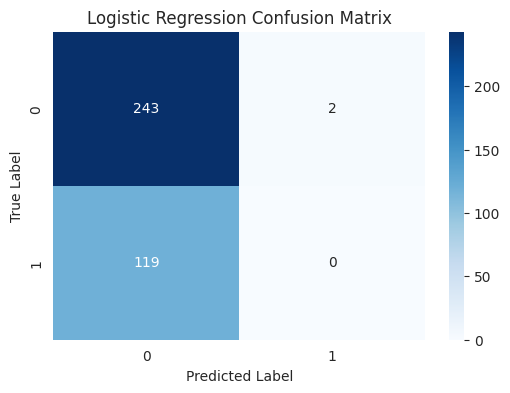

In [25]:
plt.figure(figsize=(6, 4))
sns.heatmap(logreg_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [26]:
logreg_coefficients = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": logreg_pipeline.named_steps["model"].coef_[0]
})

logreg_coefficients

,Feature,Coefficient
0,temperature_2m_mean,-0.082680
1,precipitation_sum,0.114814
2,windspeed_10m_max,-0.013786
3,travel_distance_km,-0.041305


This first baseline model provides a simple linear benchmark for the classification problem. In the next step, I will compare this model with more flexible tree-based methods in order to see whether nonlinear models can better capture the relationship between weather, travel distance, and away-team wins.

The baseline Logistic Regression model achieved an accuracy close to the majority-class baseline, but it failed to detect away wins effectively. In particular, the model predicted almost all observations as non-away-wins, which led to extremely poor recall for the positive class. This suggests that the selected weather and travel variables alone may not provide enough linear predictive signal for away-win classification.

## Part 5: Improved Logistic Regression with Class Balancing

The baseline Logistic Regression model showed a strong bias toward the majority class and failed to identify away wins effectively. To address this issue, I train a second Logistic Regression model using class balancing. This gives more importance to the minority class and helps evaluate whether a simple reweighting strategy can improve the model’s ability to detect away-team wins.

In [27]:
balanced_logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

print("Balanced Logistic Regression pipeline created successfully!")

Balanced Logistic Regression pipeline created successfully!


In [28]:
balanced_logreg_pipeline.fit(X_train, y_train)

print("Balanced Logistic Regression model trained successfully!")

Balanced Logistic Regression model trained successfully!


In [29]:
y_pred_balanced_logreg = balanced_logreg_pipeline.predict(X_test)

print("Balanced Logistic Regression predictions generated successfully!")
y_pred_balanced_logreg[:10]

Balanced Logistic Regression predictions generated successfully!


array([1, 0, 1, 0, 1, 1, 1, 1, 0, 1])

In [30]:
balanced_logreg_accuracy = accuracy_score(y_test, y_pred_balanced_logreg)

print("Balanced Logistic Regression Accuracy:", balanced_logreg_accuracy)

Balanced Logistic Regression Accuracy: 0.47802197802197804


In [31]:
print("Balanced Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_balanced_logreg))

Balanced Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.51      0.57       245
           1       0.29      0.42      0.34       119

    accuracy                           0.48       364
   macro avg       0.47      0.46      0.46       364
weighted avg       0.53      0.48      0.49       364



In [32]:
balanced_logreg_cm = confusion_matrix(y_test, y_pred_balanced_logreg)

print("Balanced Logistic Regression Confusion Matrix:")
print(balanced_logreg_cm)

Balanced Logistic Regression Confusion Matrix:
[[124 121]
 [ 69  50]]


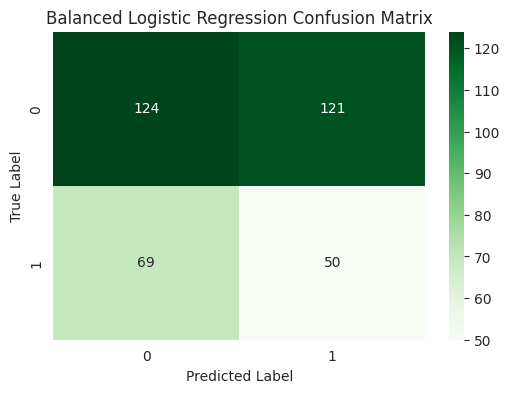

In [33]:
plt.figure(figsize=(6, 4))
sns.heatmap(balanced_logreg_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [35]:
balanced_logreg_coefficients = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": balanced_logreg_pipeline.named_steps["model"].coef_[0]
})

balanced_logreg_coefficients

,Feature,Coefficient
0,temperature_2m_mean,-0.080419
1,precipitation_sum,0.111934
2,windspeed_10m_max,-0.012983
3,travel_distance_km,-0.040374


In [36]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Balanced Logistic Regression"],
    "Accuracy": [logreg_accuracy, balanced_logreg_accuracy]
})

comparison_df

,Model,Accuracy
0,Baseline Logistic Regression,0.667582
1,Balanced Logistic Regression,0.478022


By comparing the baseline and balanced Logistic Regression models, I can evaluate whether class reweighting improves the detection of away wins. In the next step, I will move to nonlinear tree-based models and examine whether they can capture more complex patterns in the weather and distance variables.

Although the balanced Logistic Regression model achieved lower overall accuracy than the baseline model, it improved the detection of away wins by increasing recall for the minority class. This suggests that the baseline model’s higher accuracy was largely driven by majority-class prediction, while the balanced model provides a more informative benchmark for the classification task.

## Part 6: Decision Tree Classifier

As the next model, I train a Decision Tree classifier. Unlike Logistic Regression, a Decision Tree can capture nonlinear relationships and interactions between the predictors. This makes it a useful model for exploring whether more flexible decision boundaries improve away-win prediction.

In [37]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [38]:
tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [40]:
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree predictions generated successfully!")
y_pred_tree[:10]

Decision Tree predictions generated successfully!


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [41]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.6373626373626373


In [42]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.92      0.77       245
           1       0.24      0.05      0.08       119

    accuracy                           0.64       364
   macro avg       0.45      0.49      0.43       364
weighted avg       0.53      0.64      0.55       364



In [43]:
tree_cm = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(tree_cm)

Decision Tree Confusion Matrix:
[[226  19]
 [113   6]]


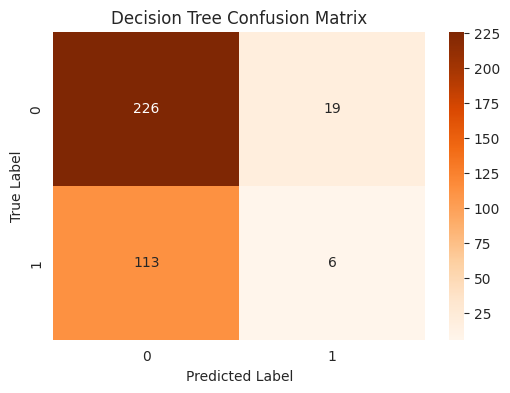

In [44]:
plt.figure(figsize=(6, 4))
sns.heatmap(tree_cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [45]:
tree_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

tree_importance_df

,Feature,Importance
1,precipitation_sum,0.432442
2,windspeed_10m_max,0.419778
0,temperature_2m_mean,0.147780
3,travel_distance_km,0.000000


In [46]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        logreg_accuracy,
        balanced_logreg_accuracy,
        tree_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Baseline Logistic Regression,0.667582
1,Balanced Logistic Regression,0.478022
2,Decision Tree,0.637363


The Decision Tree model provides a more flexible nonlinear benchmark for the classification task. By comparing its performance with the two Logistic Regression models, I can assess whether nonlinear structure in the weather and distance variables improves prediction quality.

The Decision Tree model achieved an accuracy similar to the baseline model, but it still performed poorly in identifying away wins. In particular, recall for the positive class remained very low, which suggests that the selected weather and travel variables do not provide strong nonlinear predictive structure either. Compared with the balanced Logistic Regression model, the Decision Tree achieved higher overall accuracy but worse detection of the minority class.

## Part 7: Random Forest Classifier

As the final baseline model, I train a Random Forest classifier. Random Forest combines many decision trees and usually provides more stable and robust predictions than a single tree. This model helps evaluate whether an ensemble-based nonlinear method can better predict away-team wins from weather and travel-related features.

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [48]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [49]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
y_pred_rf[:10]

Random Forest predictions generated successfully!


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [50]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6620879120879121


In [51]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.98      0.80       245
           1       0.00      0.00      0.00       119

    accuracy                           0.66       364
   macro avg       0.33      0.49      0.40       364
weighted avg       0.45      0.66      0.54       364



In [52]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[241   4]
 [119   0]]


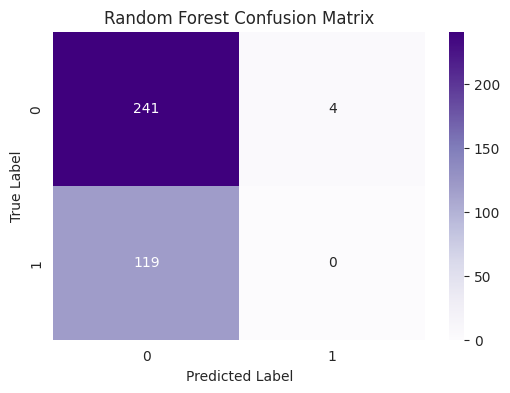

In [53]:
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Purples")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [54]:
rf_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance_df

,Feature,Importance
0,temperature_2m_mean,0.273262
2,windspeed_10m_max,0.272402
3,travel_distance_km,0.234240
1,precipitation_sum,0.220097


In [55]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logreg_accuracy,
        balanced_logreg_accuracy,
        tree_accuracy,
        rf_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Baseline Logistic Regression,0.667582
1,Balanced Logistic Regression,0.478022
2,Decision Tree,0.637363
3,Random Forest,0.662088


The Random Forest model provides an ensemble-based nonlinear benchmark for the classification task. By comparing its results with those of Logistic Regression and Decision Tree, I can evaluate whether a more robust tree-based model captures additional predictive information from the weather and travel variables.

## Part 8: Balanced Random Forest Classifier

The previous Random Forest model still showed a strong bias toward the majority class and failed to identify away wins effectively. To address this issue, I now train a class-balanced Random Forest model. This allows me to examine whether class reweighting improves the model’s ability to detect away-team wins while still benefiting from a nonlinear ensemble method.

In [56]:
balanced_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

print("Balanced Random Forest model created successfully!")

Balanced Random Forest model created successfully!


In [57]:
balanced_rf_model.fit(X_train, y_train)

print("Balanced Random Forest model trained successfully!")

Balanced Random Forest model trained successfully!


In [58]:
y_pred_balanced_rf = balanced_rf_model.predict(X_test)

print("Balanced Random Forest predictions generated successfully!")
y_pred_balanced_rf[:10]

Balanced Random Forest predictions generated successfully!


array([0, 0, 0, 0, 0, 1, 0, 1, 0, 1])

In [59]:
balanced_rf_accuracy = accuracy_score(y_test, y_pred_balanced_rf)

print("Balanced Random Forest Accuracy:", balanced_rf_accuracy)

Balanced Random Forest Accuracy: 0.521978021978022


In [60]:
print("Balanced Random Forest Classification Report:")
print(classification_report(y_test, y_pred_balanced_rf))

Balanced Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.62      0.63       245
           1       0.29      0.33      0.31       119

    accuracy                           0.52       364
   macro avg       0.47      0.47      0.47       364
weighted avg       0.54      0.52      0.53       364



In [61]:
balanced_rf_cm = confusion_matrix(y_test, y_pred_balanced_rf)

print("Balanced Random Forest Confusion Matrix:")
print(balanced_rf_cm)

Balanced Random Forest Confusion Matrix:
[[151  94]
 [ 80  39]]


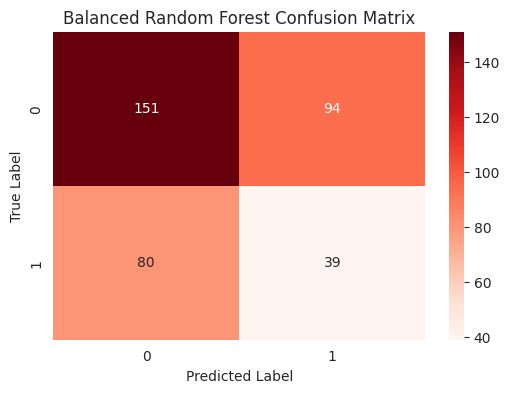

In [62]:
plt.figure(figsize=(6, 4))
sns.heatmap(balanced_rf_cm, annot=True, fmt="d", cmap="Reds")
plt.title("Balanced Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [63]:
balanced_rf_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": balanced_rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

balanced_rf_importance_df

,Feature,Importance
0,temperature_2m_mean,0.274438
2,windspeed_10m_max,0.269097
3,travel_distance_km,0.250258
1,precipitation_sum,0.206207


In [64]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        logreg_accuracy,
        balanced_logreg_accuracy,
        tree_accuracy,
        rf_accuracy,
        balanced_rf_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Baseline Logistic Regression,0.667582
1,Balanced Logistic Regression,0.478022
2,Decision Tree,0.637363
3,Random Forest,0.662088
4,Balanced Random Forest,0.521978


The balanced Random Forest model provides a final comparison point by combining nonlinear ensemble learning with class reweighting. This helps determine whether the main challenge in the classification task comes from class imbalance alone, or from the limited predictive power of the selected weather and travel features.

## Part 9: Final Model Comparison and Machine Learning Discussion

In this final machine learning section, I compare the baseline and improved classification models trained in this notebook. Since the target variable is imbalanced, overall accuracy alone is not sufficient for model selection. Therefore, I consider both general accuracy and the ability of the models to detect away-team wins, which is the minority class in this dataset.

In [65]:
comparison_df

,Model,Accuracy
0,Baseline Logistic Regression,0.667582
1,Balanced Logistic Regression,0.478022
2,Decision Tree,0.637363
3,Random Forest,0.662088
4,Balanced Random Forest,0.521978


In [66]:
model_summary_df = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        logreg_accuracy,
        balanced_logreg_accuracy,
        tree_accuracy,
        rf_accuracy,
        balanced_rf_accuracy
    ],
    "Recall_for_Away_Win": [
        classification_report(y_test, y_pred_logreg, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_balanced_logreg, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_tree, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_balanced_rf, output_dict=True)["1"]["recall"]
    ],
    "F1_for_Away_Win": [
        classification_report(y_test, y_pred_logreg, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_balanced_logreg, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_tree, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_balanced_rf, output_dict=True)["1"]["f1-score"]
    ]
})

model_summary_df

,Model,Accuracy,Recall_for_Away_Win,F1_for_Away_Win
0,Baseline Logistic Regression,0.667582,0.000000,0.000000
1,Balanced Logistic Regression,0.478022,0.420168,0.344828
2,Decision Tree,0.637363,0.050420,0.083333
3,Random Forest,0.662088,0.000000,0.000000
4,Balanced Random Forest,0.521978,0.327731,0.309524


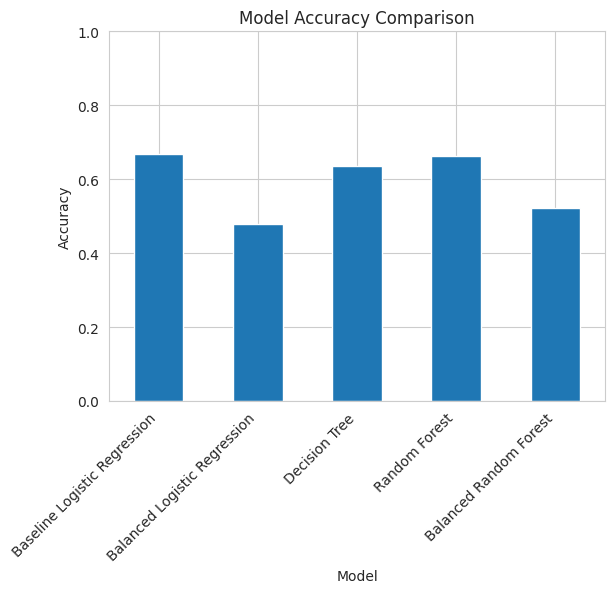

In [69]:
model_summary_df.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.show()

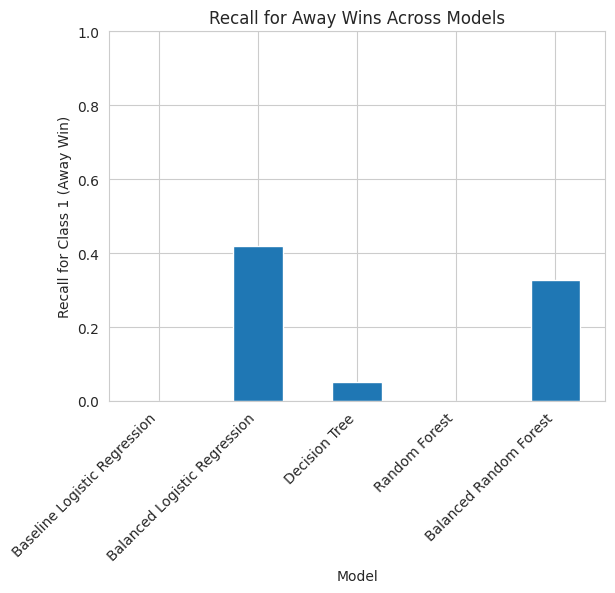

In [70]:
model_summary_df.plot(x="Model", y="Recall_for_Away_Win", kind="bar", legend=False)
plt.title("Recall for Away Wins Across Models")
plt.ylabel("Recall for Class 1 (Away Win)")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.show()

The comparison shows that the highest raw accuracy comes from models that mostly predict the majority class. However, these models fail to identify away-team wins effectively. In contrast, the class-balanced models achieve lower overall accuracy but provide more meaningful detection of the minority class.

Among the tested models, the Balanced Random Forest offers the most reasonable trade-off between overall classification performance and minority-class detection. This suggests that, although the selected weather and travel features do not provide strong predictive power, a balanced nonlinear ensemble model can still capture limited but useful signal for away-win prediction.

Overall, the machine learning results are consistent with the earlier hypothesis-testing results. Weather conditions and estimated travel distance alone do not appear to be strong predictors of away-team wins in UEFA Champions League matches. Nevertheless, the ML analysis shows that class balancing and nonlinear models can improve prediction quality slightly, especially when the goal is to detect the minority class rather than simply maximize raw accuracy.

### Final ML Remark

The machine learning stage of the project showed that the selected environmental and travel-related variables provide limited predictive information for away-team wins. While simple majority-class models achieved higher accuracy, the most informative results came from balanced models that improved minority-class detection, especially the Balanced Random Forest classifier.

## Appendix: AI Usage Disclosure

This notebook was prepared with limited AI assistance. AI was used for structuring the workflow, improving explanations, debugging code, and refining the presentation of results. All major project decisions, model choices, analyses, and final interpretations were reviewed and carried out by the student.